FILE-LEVEL STATS
train       :  45 files,   175 trajectories
validation  :  16 files,    24 trajectories
test        :  21 files,    26 trajectories

SINGLE FILE INSPECTION
File: active_matter_L_10.0_zeta_1.0_alpha_-1.0.hdf5

Attributes:
  L: 10.0
  alpha: -1.0
  dataset_name: active_matter
  grid_type: cartesian
  n_spatial_dims: 2
  n_trajectories: 3
  simulation_parameters: ['L' 'zeta' 'alpha']
  zeta: 1.0

Field shapes:
  t0_fields/concentration        shape=(3, 81, 256, 256)  dtype=float32
  t1_fields/velocity             shape=(3, 81, 256, 256, 2)  dtype=float32
  t2_fields/D                    shape=(3, 81, 256, 256, 2, 2)  dtype=float32
  t2_fields/E                    shape=(3, 81, 256, 256, 2, 2)  dtype=float32

Timesteps: 81, range: [0.00, 20.00]
Concentration: (81, 256, 256), min=0.9633, max=1.0406
Velocity:      (81, 256, 256, 2),  min=-0.8494, max=0.8245
D (orient):    (81, 256, 256, 2, 2),    min=-0.4787,   max=0.9777
E (strain):    (81, 256, 256, 2, 2),    min=-0.3379, 

KeyError: 'Unable to synchronously open object (invalid identifier type to function)'

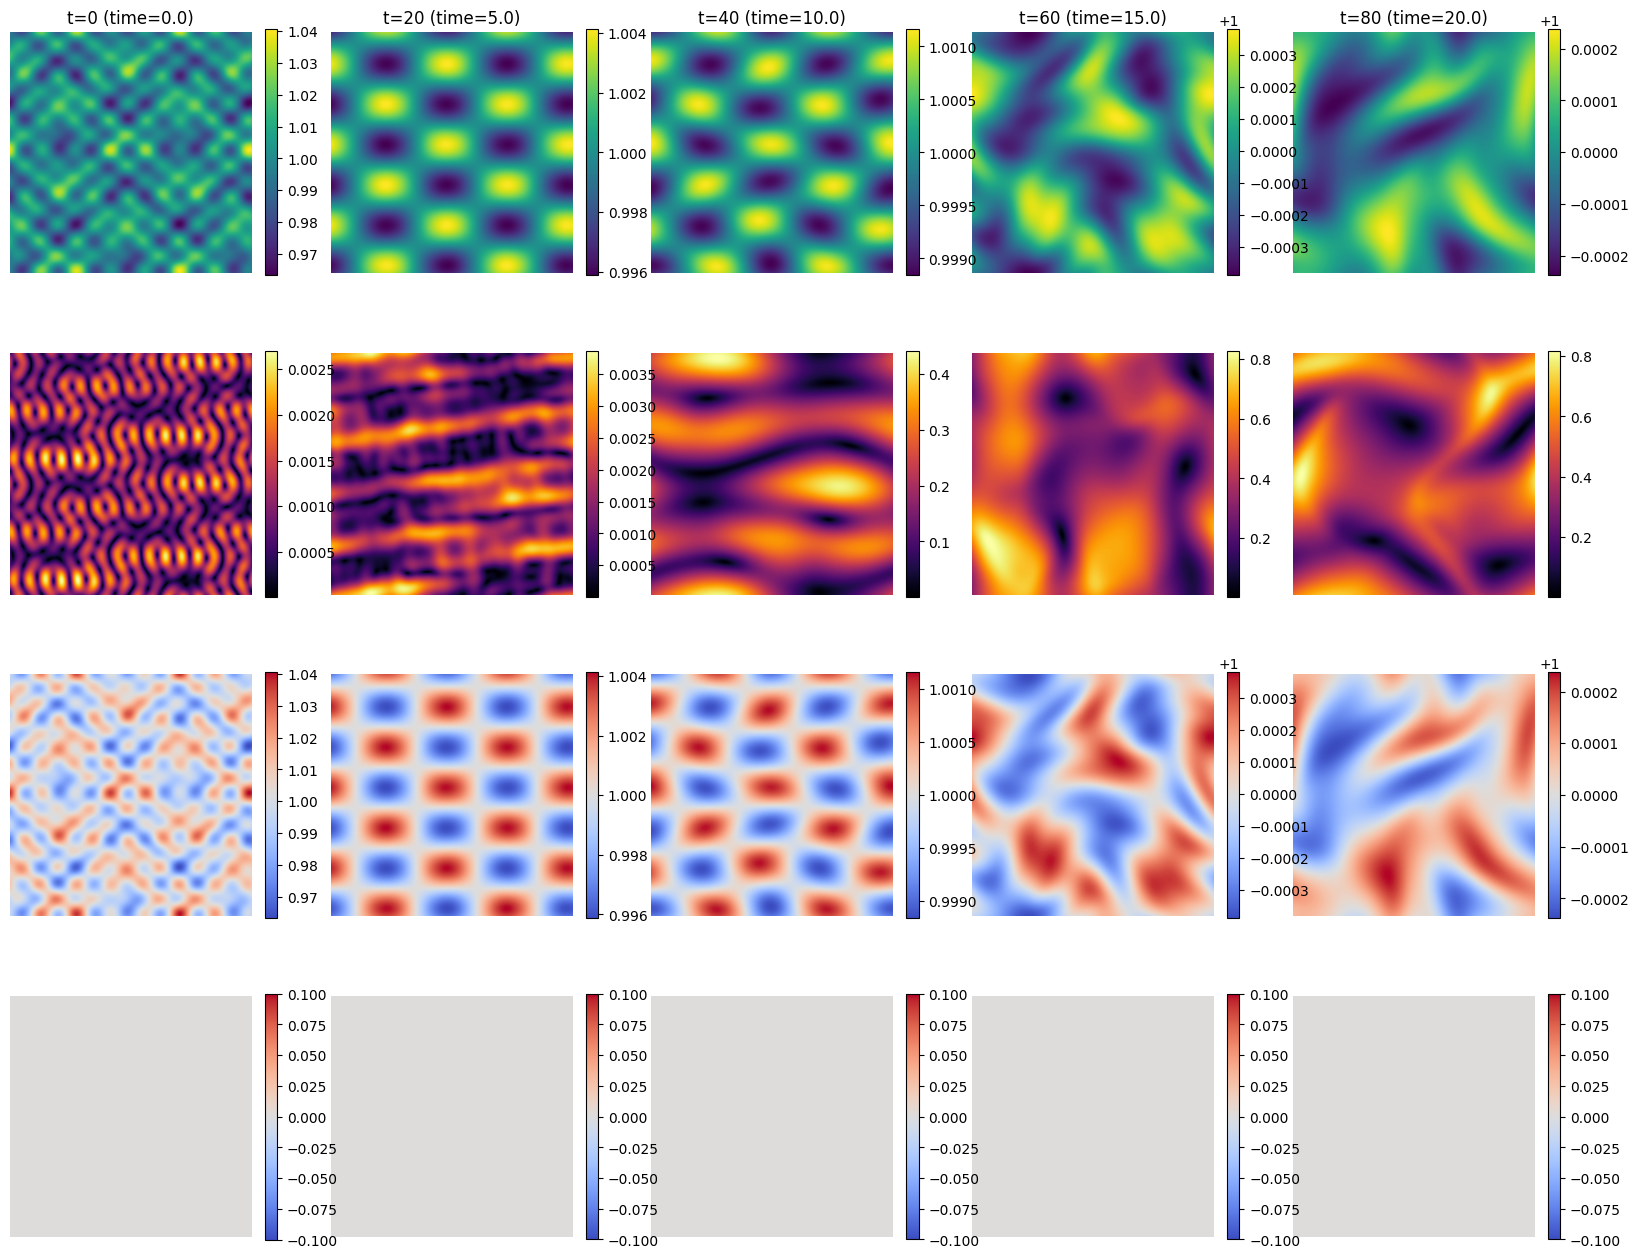

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Known field paths in active_matter HDF5 files
FIELD_PATHS = [
    ('t0_fields/concentration', 1),    # (N, T, H, W)       → 1 channel
    ('t1_fields/velocity',      2),    # (N, T, H, W, 2)    → 2 channels
    ('t2_fields/D',             4),    # (N, T, H, W, 2, 2) → 4 channels
    ('t2_fields/E',             4),    # (N, T, H, W, 2, 2) → 4 channels
]

data_dir = Path('/scratch/kk5047/dl-proj/data/active_matter/data')

# ── 1. File-level stats ──────────────────────────────────────────────
print('='*60)
print('FILE-LEVEL STATS')
print('='*60)
for split in ['train', 'validation', 'test']:
    split_dir = data_dir / split
    files = sorted(split_dir.glob('*.hdf5'))
    total_traj = 0
    for f in files:
        with h5py.File(f, 'r') as h:
            total_traj += int(h.attrs.get('n_trajectories', 1))
    print(f'{split:12s}: {len(files):3d} files, {total_traj:5d} trajectories')

# ── 2. Inspect one file in detail ────────────────────────────────────
print('\n' + '='*60)
print('SINGLE FILE INSPECTION')
print('='*60)
fpath = sorted((data_dir / 'train').glob('*.hdf5'))[0]
print(f'File: {fpath.name}\n')

with h5py.File(fpath, 'r') as f:
    print('Attributes:')
    for k, v in f.attrs.items():
        print(f'  {k}: {v}')

    print('\nField shapes:')
    for field_path, _ in FIELD_PATHS:
        ds = f[field_path]
        print(f'  {field_path:30s} shape={ds.shape}  dtype={ds.dtype}')

    # Read one trajectory for visualization
    conc = f['t0_fields/concentration'][0]    # (81, 256, 256)
    vel  = f['t1_fields/velocity'][0]          # (81, 256, 256, 2)
    D    = f['t2_fields/D'][0]                 # (81, 256, 256, 2, 2)
    E    = f['t2_fields/E'][0]                 # (81, 256, 256, 2, 2)
    times = f['dimensions/time'][:]

print(f'\nTimesteps: {len(times)}, range: [{times[0]:.2f}, {times[-1]:.2f}]')
print(f'Concentration: {conc.shape}, min={conc.min():.4f}, max={conc.max():.4f}')
print(f'Velocity:      {vel.shape},  min={vel.min():.4f}, max={vel.max():.4f}')
print(f'D (orient):    {D.shape},    min={D.min():.4f},   max={D.max():.4f}')
print(f'E (strain):    {E.shape},    min={E.min():.4f},   max={E.max():.4f}')

# ── 3. Visualize fields at selected timesteps ────────────────────────
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
timesteps = [0, 20, 40, 60, 80]

for col, t in enumerate(timesteps):
    # Row 0: concentration
    im = axes[0, col].imshow(conc[t], cmap='viridis')
    axes[0, col].set_title(f't={t} (time={times[t]:.1f})')
    plt.colorbar(im, ax=axes[0, col], fraction=0.046)

    # Row 1: velocity magnitude
    vmag = np.sqrt(vel[t, :, :, 0]**2 + vel[t, :, :, 1]**2)
    im = axes[1, col].imshow(vmag, cmap='inferno')
    plt.colorbar(im, ax=axes[1, col], fraction=0.046)

    # Row 2: D tensor (trace = D_00 + D_11)
    d_trace = D[t, :, :, 0, 0] + D[t, :, :, 1, 1]
    im = axes[2, col].imshow(d_trace, cmap='coolwarm')
    plt.colorbar(im, ax=axes[2, col], fraction=0.046)

    # Row 3: E tensor (trace = E_00 + E_11)
    e_trace = E[t, :, :, 0, 0] + E[t, :, :, 1, 1]
    im = axes[3, col].imshow(e_trace, cmap='coolwarm')
    plt.colorbar(im, ax=axes[3, col], fraction=0.046)

for ax in axes.flat:
    ax.axis('off')

axes[0, 0].set_ylabel('Concentration', fontsize=14)
axes[1, 0].set_ylabel('|Velocity|', fontsize=14)
axes[2, 0].set_ylabel('Tr(D) orient.', fontsize=14)
axes[3, 0].set_ylabel('Tr(E) strain', fontsize=14)

plt.suptitle(f'{fpath.name}\nα={f.attrs["alpha"]}, ζ={f.attrs["zeta"]}', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ── 4. Distribution of alpha and zeta across splits ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for split in ['train', 'validation', 'test']:
    alphas, zetas = [], []
    for fp in sorted((data_dir / split).glob('*.hdf5')):
        with h5py.File(fp, 'r') as f:
            n = int(f.attrs.get('n_trajectories', 1))
            alphas.extend([float(f.attrs['alpha'])] * n)
            zetas.extend([float(f.attrs['zeta'])] * n)
    axes[0].hist(alphas, alpha=0.5, label=f'{split} ({len(alphas)})', bins=20)
    axes[1].hist(zetas,  alpha=0.5, label=f'{split} ({len(zetas)})',  bins=20)

axes[0].set_title('α distribution'); axes[0].legend()
axes[1].set_title('ζ distribution'); axes[1].legend()
plt.tight_layout()
plt.show()
